## imports

In [1]:
import os
import time
import traceback
try: import uncertainties
except: os.system("pip install uncertainties")

In [22]:
from uncertainties import ufloat
from uncertainties import unumpy as unp
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import scipy.optimize as opt
from scipy.optimize import curve_fit
import pandas as pd
import scipy.signal as sig

@np.vectorize
def pr(obj,label=None, split = False):
  if callable(obj):
    def new_func(*args,**kwargs):
      result=obj(*args,**kwargs)
      if label: print(label.format(*result)) if split else print(label.format(result))
      else:
        if split:
          for r in result: print(r)
        else: print(result)
      return result
    return new_func

  else:
    if label: print(label.format(*obj)) if split else print(label.format(obj))
    else:
      if split:
        for r in obj: print(r)
      else: print(obj)
    return obj


agree = lambda x,y: (np.abs(x.n-y.n) <= np.sqrt(np.square(x.s)+np.square(y.s)))
v_err = lambda v: 0.013*np.abs(v) + 0.008*(10**np.floor(np.log10(v)))
a_err = lambda a: 0.015*np.abs(a) + 0.008*(10**np.floor(np.log10(a)))
r_err = lambda r: 0.01*np.abs(r) + 0.005*(10**np.floor(np.log10(r))) if r!=0 else 0.005
c_err = lambda f: 0.04*np.abs(f) + 0.05*(10**np.floor(np.log10(f))) if f!=0 else 0.5

@np.vectorize
def u_convert(arr,err_fn):
  if callable(err_fn):
    return ufloat(arr,err_fn(arr))
  else: return ufloat(arr,err_fn)

def compare(a,b, prefix="", labels = ("Predicted: {:.3e}","Measured: {:.3e}","agree: {}"), ):
  print(" | ".join((prefix,)+labels).format(a,b,agree(a,b)))

pi = np.pi
sqrt = np.sqrt
sin = np.sin
cos = np.cos
tan = np.tan
ln = np.log
log = np.log10
square = np.square
exp = np.exp

u=ufloat
uc = u_convert
r_c = lambda x: u_convert(x,r_err)
nom = unp.nominal_values
std = unp.std_devs

## initial angle testing

In [3]:
# Two Microphone System Angle Approx

In [4]:

ssound = 343  # speed of sound in m/s
f = 4e4 # frequency of sound in Hz

d = u(0.107, 0.001) # distance between microphones in m
r = u(2.45, 0.02)  # distance from source to center of microphones in m

#lag = d*cos(theta)/s

# positions of microphones in m
shifts = np.array([(u(0,1e4), u(0,1e-6)), (u(1e-2,1e-4), u(1.5e-6,1.5e-6)), 
                    (u(2e-2,1e-4), u(3.5e-6, 1.5e-6)), (u(5e-2,1e-4), u(7.3e-6, 1.5e-6)),
                    (u(10e-2,1e-4), u(12.5e-6, 1.5e-6)), (u(15e-2,1e-4), u(20.5e-6, 1.5e-6)), 
                    (u(20e-2,1e-4), u(25.5e-6, 2e-6)), (u(25e-2,1e-4), u(28.5e-6, 2e-6)), (u(30e-2,1e-4), u(38e-6, 2e-6)), (u(40e-2,1e-4), u(48e-6, 2e-6))])  # time shifts of microphones in s
mictest2 = pd.DataFrame(shifts, columns=["position", "time_shift"])

lag = mictest2["time_shift"]

theta = unp.arcsin(lag*ssound/d)*180/pi
theta_th = unp.arctan(mictest2["position"]/r)*180/pi

for th2, th1,pos in zip(theta,theta_th,mictest2["position"]):
    compare(th1, th2, f"position: {pos:.2f} m", ("Predicted angle: {:.2f}°","Measured angle: {:.2f}°","agree: {}"))



position: 0.00+/-10000.00 m | Predicted angle: 0.00+/-233860.32° | Measured angle: 0.00+/-0.18° | agree: True
position: 0.01+/-0.00 m | Predicted angle: 0.23+/-0.00° | Measured angle: 0.28+/-0.28° | agree: True
position: 0.02+/-0.00 m | Predicted angle: 0.47+/-0.00° | Measured angle: 0.64+/-0.28° | agree: True
position: 0.05+/-0.00 m | Predicted angle: 1.17+/-0.01° | Measured angle: 1.34+/-0.28° | agree: True
position: 0.10+/-0.00 m | Predicted angle: 2.34+/-0.02° | Measured angle: 2.30+/-0.28° | agree: True
position: 0.15+/-0.00 m | Predicted angle: 3.50+/-0.03° | Measured angle: 3.77+/-0.28° | agree: True
position: 0.20+/-0.00 m | Predicted angle: 4.67+/-0.04° | Measured angle: 4.69+/-0.37° | agree: True
position: 0.25+/-0.00 m | Predicted angle: 5.83+/-0.05° | Measured angle: 5.24+/-0.37° | agree: False
position: 0.30+/-0.00 m | Predicted angle: 6.98+/-0.06° | Measured angle: 7.00+/-0.38° | agree: True
position: 0.40+/-0.00 m | Predicted angle: 9.27+/-0.07° | Measured angle: 8.85+/-

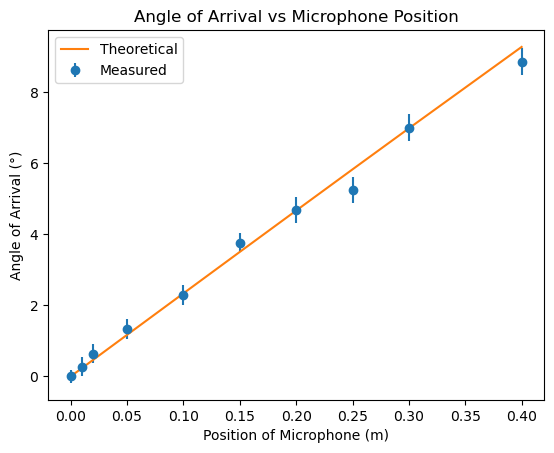

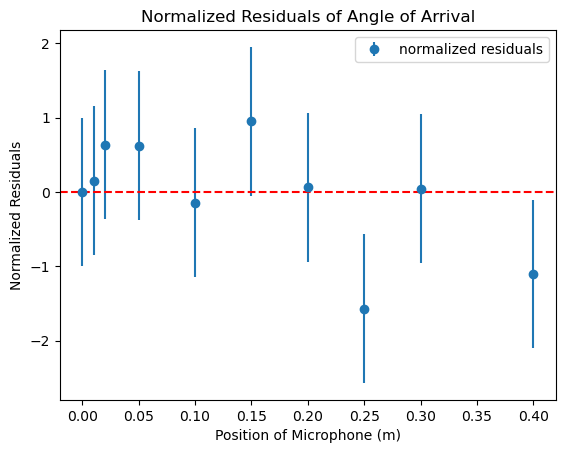

Chi-squared: 5.43
Chi-squared: 5.43


In [5]:
plt.errorbar(unp.nominal_values(mictest2["position"]), unp.nominal_values(theta), yerr=unp.std_devs(theta), fmt='o', label="Measured")
plt.plot(unp.nominal_values(mictest2["position"]), unp.nominal_values(theta_th), label="Theoretical")
plt.xlabel("Position of Microphone (m)")
plt.ylabel("Angle of Arrival (°)")
plt.title("Angle of Arrival vs Microphone Position")
plt.legend()
plt.show()

plt.errorbar(unp.nominal_values(mictest2["position"]),(unp.nominal_values(theta)-unp.nominal_values(theta_th))/unp.std_devs(theta),yerr = np.ones_like(theta), fmt='o', label="normalized residuals")
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Position of Microphone (m)")
plt.ylabel("Normalized Residuals")
plt.title("Normalized Residuals of Angle of Arrival")
plt.legend()
plt.show()
chisq_2mic = pr(np.sum(np.square((unp.nominal_values(theta)-unp.nominal_values(theta_th))/unp.std_devs(theta))),"Chi-squared: {:.2f}")


## Wavegen Setup

In [6]:
"""
Important objects:
    ADSHardware (class): a collection of methods for interfacing with the ADS
        variables:
            handle: address to connect to the ADS
        functions:
            startup: connects to ADS
            open_scope: opens connection to oscilloscope
            trigger_scope: sets trigger level for scope (buggy)
            read_scope: collects data from oscilloscope
            close_scope: closes connection to oscilloscope
            use_wavegen: outputs function at wavegen
            close_wavegen: closes connection to wavegen
            disconnect: closes connection to ADS
    oscilloscope_run (function): opens connection to and collects data from scope
    wavegen_functions (dict): easy names to access major types of functions wavegen can output

"""
from WF_SDK import device
from WF_SDK import scope
from WF_SDK import wavegen

In [7]:
class ADSHardware():
    """Class of functions for interfacing with the ADS.
    """

    def __init__(self):
        self.handle = None

    def startup(self):
        """Connects to the ADS. Defines 'handle', the address to the ADS.
        Must be run at the beginning of every program using the ADS.
        """
        self.handle = device.open()

    def open_scope(self, buffer_size=1000, sample_freq=1e6):
        """Opens connection to the scope.

        Args:
            buffer_size (int, optional): How many data points are temporarily stored
            before being returned. The buffer is a temporary slot for storing a small amount of
            data before it is transferred to its final destination. Defaults to 1000.
            sample_freq (int, optional): How frequently the oscilloscope will sample
            from the input. Defaults to 1e6. You can decrease this if you have too
            many data points/the function is taking awhile to run for the time scale you need.
            (16e3 can be a reasonable selection.)
        """
        scope.open(self.handle, buffer_size=buffer_size, sampling_frequency=sample_freq)

    def trigger_scope(self, channel=1, level=0.1):
        """Sets trigger level for the scope. Kind of a buggy function; not used.

        Args:
            channel (int, optional): Selects which channel of scope to read out. 
            Defaults to 1.
            level (float, optional): Sets trigger level for scope. Defaults to 0.1.
        """
        scope.trigger(self.handle, enable=True, source=scope.trigger_source.analog, channel=channel,
                      edge_rising=True, level=level)

    def read_scope(self, channel=1):
        """Collects data from the scope.

        Args:
            channel (int, optional): Which channel to read from. Defaults to 1.

        Returns:
            buffer (array): An array of output data points. The buffer is a temporary slot 
            for storing a small amount of data before it is transferred to its final destination.
        """
        buffer = scope.record(self.handle, channel=channel)
        return buffer

    def close_scope(self):
        """Closes connection to the scope.
        """
        scope.close(self.handle)

    def use_wavegen(self, channel=1, function=wavegen.function.sine, offset_v=0, freq_hz=1e3, amp_v=1):
        """Runs the wavegen producing function with given parameters.

        Args:
            channel (int, optional): Which channel output is at. Defaults to 1.
            function (function object, optional): What type of function to output. 
            Defaults to wavegen.function.sine.
            offset (int, optional): Voltage offset (V). Defaults to 0.
            freq (int, optional): Frequency (Hz). Defaults to 1e3.
            amp (int, optional): Amplitude (V). Defaults to 1.
        """
        wavegen.generate(self.handle, channel=channel, function=function, offset=offset_v,
                         frequency=freq_hz, amplitude=amp_v)

    def close_wavegen(self):
        """Closes wavegen.
        """
        wavegen.close(self.handle)

    def disconnect(self):
        """Closes ADS connection. Must be run at the end of every program.
        """
        device.close(self.handle)

def oscilloscope_run(ads_object: ADSHardware, duration: int, channel: int, sampling_freq=500):
    """Collects data from the oscilloscope.

    Args:
        ads_object (ADSHardware object): the ADS being used
        duration (int): time length of trace to collect in seconds
        channel (int): which channel to collect data from
        sampling_freq (int, optional): How frequently the oscilloscope will sample
        from the input. Defaults to 500. You can decrease this if you have too
        many data points/the function is taking awhile to run for the time scale you need.
        (16e3 can be a reasonable selection.)

    Returns:
        data (dict): has two keys, "x" and "y" which have time (ms) and voltage (V) data
    """
    buffer_size = int(duration * sampling_freq)
    data = {}
    ads_object.open_scope(sample_freq=sampling_freq, buffer_size=buffer_size)

    MS_CONVERSION = 1e3

    buffer = ads_object.read_scope()
    data["y"] = buffer

    # MODIFY THE LINE BELOW THIS ONE IN L10.2(d)
    data["x"] = np.arange(buffer_size)*MS_CONVERSION/sampling_freq

    ads_object.close_scope()
    return data

def oscilloscope_run(ads_object: ADSHardware, duration: int, channel: int, sampling_freq=500):
    """Collects data from the oscilloscope.

    Args:
        ads_object (ADSHardware object): the ADS being used
        duration (int): time length of trace to collect in seconds
        channel (int): which channel to collect data from
        sampling_freq (int, optional): How frequently the oscilloscope will sample
        from the input. Defaults to 500. You can decrease this if you have too
        many data points/the function is taking awhile to run for the time scale you need.
        (16e3 can be a reasonable selection.)

    Returns:
        data (dict): has two keys, "x" and "y" which have time (ms) and voltage (V) data
    """
    
    buffer_size = int(duration * sampling_freq)
    data = {}
    ads_object.open_scope(sample_freq=sampling_freq, buffer_size=buffer_size)

    MS_CONVERSION = 1e3

    buffer = ads_object.read_scope()

    data["y"] = buffer
    data["x"] = np.arange(buffer_size)*MS_CONVERSION/sampling_freq

    ads_object.close_scope()

    return data

wavegen_functions = {"sine":wavegen.function.sine, "square":wavegen.function.square,
                     "triangle":wavegen.function.triangle, "dc":wavegen.function.dc}

In [8]:
# Startup ADS

ads1 = None
ads1 = ADSHardware()
try: ads1.disconnect()
except: pass
ads1.startup()

ads2 = None
ads2 = ADSHardware()
try: ads2.disconnect()
except: pass
ads2.startup()
ads1.handle.handle = 1
ads2.handle.handle = 2
print(ads1.handle.handle)
print(ads2.handle.handle)

adsT = None
adsR = None

# Ads with highest recieved signal is adsT
ads1.use_wavegen(channel=1, function=wavegen.function.sine, offset_v=0, freq_hz=4e4, amp_v=1)
datatest1 = oscilloscope_run(ads1, duration=0.1, channel=1, sampling_freq=16e3)
ads1.close_wavegen()
ads2.use_wavegen(channel=1, function=wavegen.function.sine, offset_v=0, freq_hz=4e4, amp_v=1)
datatest2 = oscilloscope_run(ads2, duration=0.1, channel=1, sampling_freq=16e3)
ads2.close_wavegen()

if np.max(np.abs(datatest1["y"])) > np.max(np.abs(datatest2["y"])):
    adsT = ads1
    adsR = ads2
    print("ads1 is transmitter, ads2 is receiver")
else:
    adsT = ads2
    adsR = ads1
    print("ads2 is transmitter, ads1 is receiver")



Connected to Analog Discovery 2
Device handle: 1
Connected to Analog Discovery 2
Device handle: 2
1
2
ads1 is transmitter, ads2 is receiver


## 1D Non Degenerate Measures (3 mics) Full

In [9]:
# measure function, split between ADST and ADSR

def measure(duration=0.1, channels={"R":[1,2],"T":[1]}, sampling_freq=16e3):

    buffer_size = int(duration * sampling_freq)
    data = {}

    adsT.open_scope(sample_freq=sampling_freq, buffer_size=buffer_size)
    adsR.open_scope(sample_freq=sampling_freq, buffer_size=buffer_size)

    MS_CONVERSION = 1e3
    buffer = []
    for key, channel in channels.items():
        if key == "T":
            for ch in channel:
                buffer.append(adsT.read_scope(ch))
        elif key == "R":
            for ch in channel:
                buffer.append(adsR.read_scope(ch))

    data["y"] = buffer
    data["x"] = np.arange(buffer_size)*MS_CONVERSION/sampling_freq

    adsT.close_scope()
    adsR.close_scope()

    return data

In [10]:
adsR.handle.handle

2

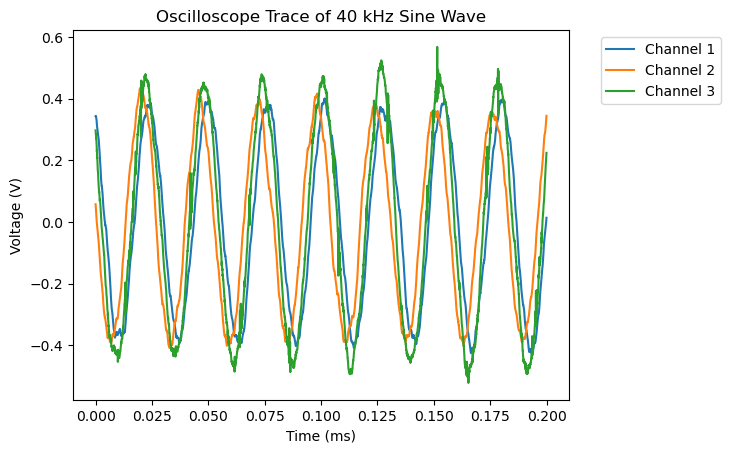

In [19]:
# 1D collect data
# Want to run wavegen at 40 kHz, 5 V amplitude, 0 V offset, for 1 second, and collect data from channel 1 of the scope at a sampling frequency of 4000 kHz. Then plot the data.

adsT.use_wavegen(channel=1, function=wavegen_functions["sine"], offset_v=0, freq_hz=40e3, amp_v=1)
time.sleep(.1)
data = measure(duration=2e-4, sampling_freq=16e6)
#data = oscilloscope_run(ads1, duration=0.001, channel=1, sampling_freq=4e6)
adsT.close_wavegen()

for channel in data["y"]:
    plt.plot(data["x"], channel, label="Channel {}".format(data["y"].index(channel)+1))
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (V)")
plt.title("Oscilloscope Trace of 40 kHz Sine Wave")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.savefig("dumping_ground/1DArray.png")
plt.show()

Fitted parameters for Channel 1: A = 0.39, f = 38.36 kHz, phi = 2.12 rad, D = -0.00 V
Fitted parameters for Channel 2: A = 0.38, f = 38.41 kHz, phi = 3.00 rad, D = -0.00 V
Fitted parameters for Channel 3: A = 0.46, f = 38.35 kHz, phi = 2.49 rad, D = -0.00 V


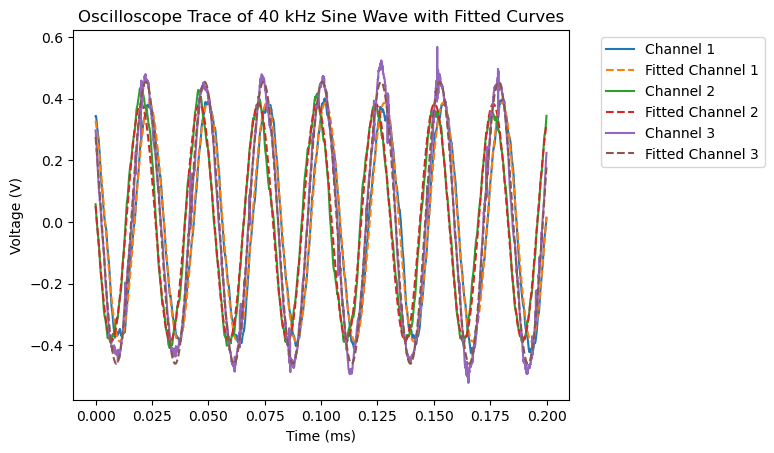

Lags (s): [8.81656218626785e-06, 1.2438355182576383e-05, 1.0320831760078057e-05]


In [ ]:
# Fit sins to each channel trace. Get phase --> lag

def fit_sine(x, A, f, phi, D):
    return A * np.sin(2 * np.pi * f * x + phi) + D

lags = []
fs = []

# Plot the fitted curve against the data
for i, channel in enumerate(data["y"]):
    popt, pcov = curve_fit(fit_sine, data["x"], channel, p0=[1, 40, 0, 0], bounds=([0, 30, 0, -1], [3, 50, 2*np.pi, 1]), maxfev=100000)
    A, f, phi, D = popt
    print("Fitted parameters for Channel {}: A = {:.2f}, f = {:.2f} kHz, phi = {:.2f} rad, D = {:.2f} V".format(i+1, A, f, phi, D))
    lags.append(phi/(2*np.pi*f*1e3)) # convert lag to seconds
    fs.append(f*1e3) # convert frequency to Hz
    fitted_curve = fit_sine(data["x"], A, f, phi, D)
    plt.plot(data["x"], channel, label="Channel {}".format(i+1))
    plt.plot(data["x"], fitted_curve, label="Fitted Channel {}".format(i+1), linestyle='--')
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (V)")
plt.title("Oscilloscope Trace of 40 kHz Sine Wave with Fitted Curves")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.savefig("dumping_ground/1DArray_fit.png")
plt.show()

print("Lags (s):", lags)


In [ ]:
peaks 
for i, channel in enumerate(data["y"]):
    peaks, props = sp.signal.find_peaks(channel, distance = 200)
    peak_times = data["x"][peaks]
    

In [23]:
def make_lag_fn(signal_distance,reciever_distance, frequency):
    def lag_fn(theta):
        r1 = signal_distance
        d12 = reciever_distance
        r2 = np.sqrt(r1**2 - 2*r1*d12*np.cos(theta) + d12**2) # |r - d| vector
        total_delay = (r2 - r1)/ssound
        mod_delay = np.mod(total_delay,1/frequency)
        return mod_delay
    return lag_fn

In [25]:
# Measured Lags
lagx_1d_meas = np.mod(lags[1] - lags[0], 1/f) # lag between mic 1 and mic 2
lagxb_1d_meas = np.mod(lags[2] - lags[0], 1/f) # Lag between mic 1 and mic 2b

# Extras
r_fixed = 1.00 # fixed distance from souce to origin microphone (mic 1).
print(f"fixed radius: {r_fixed:.2f} m")
f = np.average(fs)
print(f"Measured frequency: {f:.2f} Hz")

# Array geometry
d12_1d = (ufloat(4.95,0.05)*1e-2).n # distance between mic 1 at origin and mic 2 on y
d1b_1d = (ufloat(10.90,0.05)*1e-2).n # distance between mic 1 at origin and mic 3 on y at different distance from 2

# 1D position finder (2 mics, 1 origin, 1:x) for mics along an arc of constant r, with angle theta from the x axis
lagx_1d = make_lag_fn(r_fixed,d12_1d,f)

# extra mic for non degenerate (place another mic along x such that d12 and d1x are coprime)
lagxb_1d = make_lag_fn(r_fixed,d1b_1d,f)

def equations1d(vars, lagx_1d_meas, lagxb_1d_meas):
    (theta,_) = vars
    eq1 = lagx_1d(theta) - lagx_1d_meas
    eq2 = lagxb_1d(theta) - lagxb_1d_meas
    return [eq1, eq2]

theta_1d_guess = 60*np.pi/180 # initial guess for theta
theta_1d, _ = opt.fsolve(equations1d, (theta_1d_guess, 0), args=(lagx_1d_meas, lagxb_1d_meas),maxfev=100000)

print(f"theta={theta_1d*180/pi:.2f}°")


fixed radius: 1.00 m
Measured frequency: 38372.19 Hz
theta=58.01°


C:\Users\paulm\AppData\Local\Temp\ipykernel_36836\18925363.py:28: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  theta_1d, _ = opt.fsolve(equations1d, (theta_1d_guess, 0), args=(lagx_1d_meas, lagxb_1d_meas),maxfev=100000)


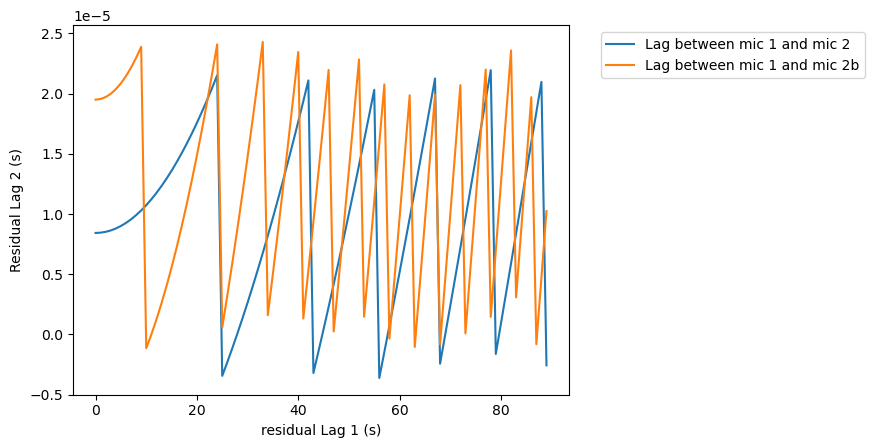

In [32]:
#plt.plot(lagxb_1d(np.arange(0,90)*pi/180)-lagxb_1d_meas, lagx_1d(np.arange(0,90)*pi/180)-lagx_1d_meas, label="Lag between mic 1 and mic 2")
plt.plot(np.arange(0,90), lagx_1d(np.arange(0,90)*pi/180)-lagx_1d_meas, label="Lag between mic 1 and mic 2")
plt.plot(np.arange(0,90), lagxb_1d(np.arange(0,90)*pi/180)-lagxb_1d_meas, label="Lag between mic 1 and mic 2b")

plt.xlabel("residual Lag 1 (s)")
plt.ylabel("Residual Lag 2 (s)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

(11, 25)
[  152   223   285   481   574   841  1027  1064  1209  1553  1597  1755
  2122  2131  2203  2279  2724  2768  3073  3109  3159  3162  3233  3351
  3477  3559  3682  3703  4164  4208  4399  4654  4786  4842  5501  5825
  5958  6083  6227  6244  6354  6387  6387  6487  6788  6825  6972  7074
  7390  7410  7426  7459  7646  8098  8206  8509  9074  9083  9139  9164
  9237  9363  9399  9443  9446  9464  9798 10021 10070 10240 10562 10861
 11108 11148 11290 11372 11989 12040 12046 12140 12148 12148 12264 12429
 12638 12694 12992 13411 13485 13611 13752 13765 14300 14845 14900 14925
 14980 15050 15277 15349 15676 15752 15859 15873 16096 16376 16743 16896
 17176 17500 17750 17801 17961 18011 18054 18170 18242 18275 18315 18631
 18713 18752 19000 19303 19593 19686 19717 19953 20124 20713 20741 20811
 20831 20932 21352 21655 21658 21686 22345 22495 22658 22735 23535 23543
 23563 23707 23931 24003 24036 24086 24360 24581 25029 25313 25352 25499
 25505 25623 25919 26167 26444 26554 26717

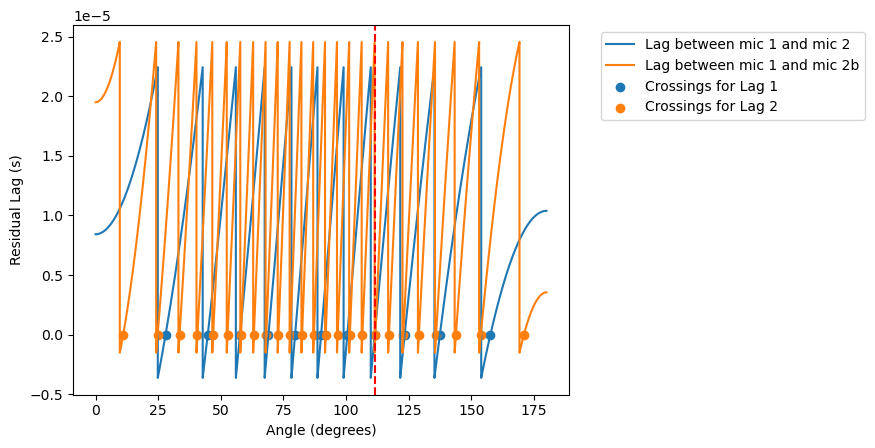

In [83]:
bigrange = np.linspace(0,180,100000)*pi/180
plt.plot(bigrange*180/pi, lagx_1d(bigrange)-lagx_1d_meas, label="Lag between mic 1 and mic 2")
plt.plot(bigrange*180/pi, lagxb_1d(bigrange)-lagxb_1d_meas, label="Lag between mic 1 and mic 2b")

cross1 = np.where(np.diff(np.sign(lagx_1d(bigrange)-lagx_1d_meas))>0)[0]
cross2 = np.where(np.diff(np.sign(lagxb_1d(bigrange)-lagxb_1d_meas))>0)[0]
plt.scatter(bigrange[cross1]*180/pi,np.zeros_like(cross1), label="Crossings for Lag 1")
plt.scatter(bigrange[cross2]*180/pi,np.zeros_like(cross2), label="Crossings for Lag 2")
plt.xlabel("Angle (degrees)")
plt.ylabel("Residual Lag (s)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

pairwise_dists = np.abs(cross1[:,np.newaxis]-cross2[np.newaxis,:])
print(np.shape(pairwise_dists))

best_cross_indices = np.array(np.unravel_index(np.argsort(pairwise_dists, axis = None), pairwise_dists.shape)).T
#print(best_cross_indices)
print(pairwise_dists[best_cross_indices[:,0], best_cross_indices[:,1]])
print(best_cross_indices)
sorted_cross = np.array([cross1[best_cross_indices[:,0]], cross2[best_cross_indices[:,1]]]).T
print(sorted_cross)

theta_estimate = np.mean([bigrange[sorted_cross[0,0]], bigrange[sorted_cross[0,1]]])*180/pi
print(f"Best crossing estimate for theta: {theta_estimate:.2f}°")
plt.axvline(theta_estimate, color='red', linestyle='--', label="Theta Estimate")

plt.show()


In [15]:
# 2D position finder (L shape)
lag12 = lambda r1, theta : (np.sqrt(r1**2 - 2*r1*d12_2d*np.sin(theta) + d12_2d**2) - r1)/ssound
lag13 = lambda r1, theta : (np.sqrt(r1**2 - 2*r1*d13_2d*np.cos(theta) + d13_2d**2) - r1)/ssound

# 2D position finder non degenerate (place another mic along x such that d12 and d1x are coprime)
lag1b = lambda r1, theta : (np.sqrt(r1**2 - 2*r1*d1b_2d*np.sin(theta) + d1b_2d**2) - r1)/ssound

# Solve for theta and rs using lag12, lag13, and lag1b to remove degeneracy

def equations2d_nondeg(vars, lag12_meas, lag13_meas, lag1b_meas):
    r1, theta = vars
    eq1 = lag12(r1, theta) - lag12_meas
    eq2 = lag13(r1, theta) - lag13_meas
    eqd = lag1b(r1, theta) - lag1b_meas
    return [eq1, eq2, eqd]

[r1_guess, theta_guess] = [2.5, 45*np.pi/180]  # initial guess for r1 and theta, meters and radians
results_2d_nondeg = opt.fsolve(equations2d_nondeg, (r1_guess, theta_guess), args=(lag12_meas, lag1b_meas))



NameError: name 'lag12_meas' is not defined

In [ ]:
# 3D position finder (3d axis shape, 1 origin, 4:x, 3:y, 2:z)
lag12 = lambda r1, theta : (np.sqrt(r1**2 - 2*r1*d12*np.cos(theta)) - r1)/ssound
lag13 = lambda r1, phi, theta : (np.sqrt(r1**2 - 2*r1*d13*np.sin(phi)*np.sin(theta)) - r1)/ssound
lag14 = lambda r1, phi, theta : (np.sqrt(r1**2 - 2*r1*d14*np.cos(phi)*np.sin(theta)) - r1)/ssound

# 3D position finder non degenerate (place another mic along z such that d12 and d1x are coprime)
Lag1b = lambda r1, theta : (np.sqrt(r1**2 - 2*r1*d1b*np.cos(theta) + d**2) - r1)/ssound
# Solve for theta and rs using lag12, lag13, and lag1b

